In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('data/students.csv')
df.sample(5)

,Student_ID,Age,Height_cm,Weight_kg,Study_Hours,Monthly_Expense
146,147,20,176,72,3,7779
104,105,19,157,54,8,3997
241,242,24,159,75,6,4065
168,169,24,166,79,4,9196
208,209,23,170,57,7,7299


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Student_ID       250 non-null    int64
 1   Age              250 non-null    int64
 2   Height_cm        250 non-null    int64
 3   Weight_kg        250 non-null    int64
 4   Study_Hours      250 non-null    int64
 5   Monthly_Expense  250 non-null    int64
dtypes: int64(6)
memory usage: 11.8 KB


In [ ]:
df.describe()

,Student_ID,Age,Height_cm,Weight_kg,Study_Hours,Monthly_Expense
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,21.576000,173.668000,67.516000,4.372000,6875.160000
std,72.312977,2.248655,10.941877,12.787801,2.316697,2834.409113
min,1.000000,18.000000,155.000000,45.000000,1.000000,2005.000000
25%,63.250000,20.000000,163.250000,56.000000,2.000000,4389.000000
50%,125.500000,21.500000,175.500000,68.000000,4.000000,6788.500000
75%,187.750000,24.000000,183.000000,79.000000,6.000000,9176.250000
max,250.000000,25.000000,190.000000,90.000000,8.000000,11984.000000


In [29]:
X = df[['Height_cm']]
y = df[['Weight_kg']]

<Axes: xlabel='Height_cm', ylabel='Weight_kg'>

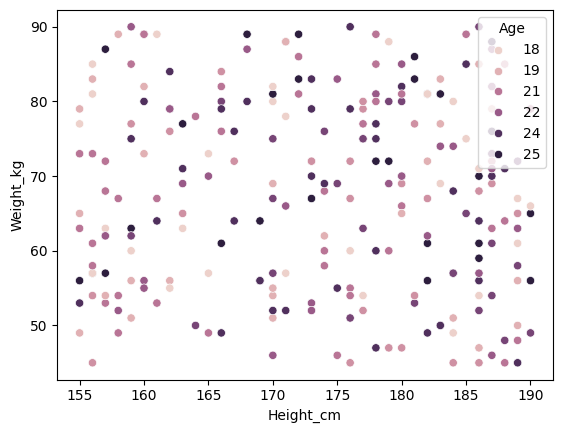

In [ ]:
sns.scatterplot(x = 'Height_cm', y = 'Weight_kg', hue = 'Age', data = df)

<Axes: >

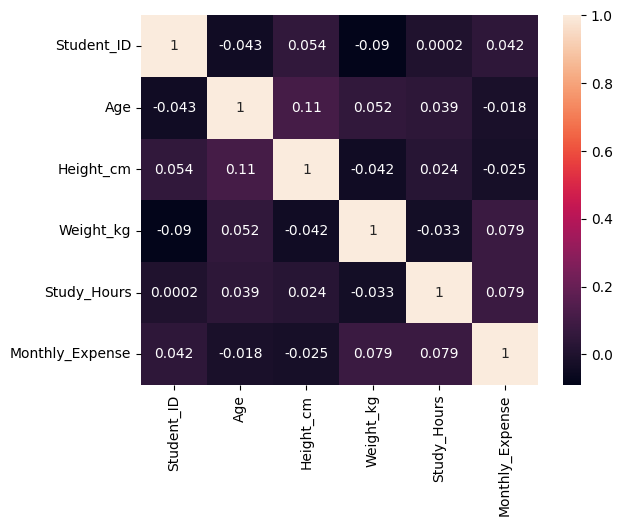

In [66]:
sns.heatmap(df.corr(), annot = True)

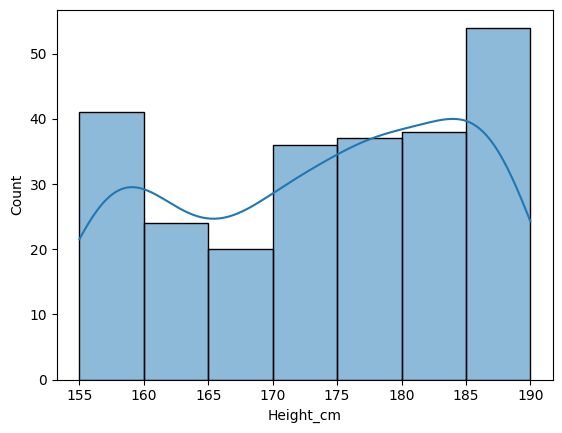

In [50]:
sns.histplot(X['Height_cm'], bins = 7, kde = True)
plt.show()

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)


In [38]:
X_scaled.describe()

,Height_cm
count,2.500000e+02
mean,-5.613288e-16
std,1.002006e+00
min,-1.709528e+00
25%,-9.540318e-01
50%,1.677660e-01
75%,8.545810e-01
max,1.495608e+00


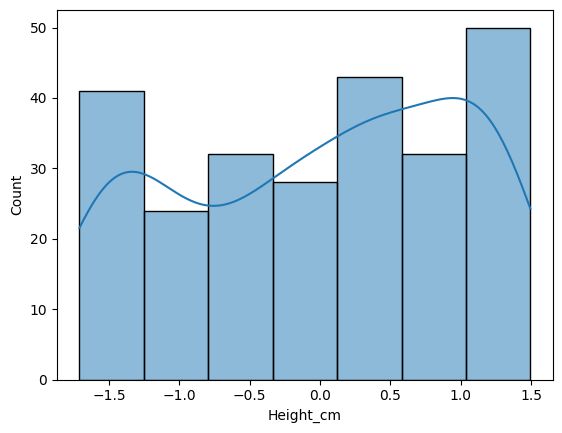

In [51]:
sns.histplot(X_scaled['Height_cm'], bins = 7, kde = True)
plt.show()

In [52]:
X_Normalized = MinMaxScaler().fit_transform(X)
X_Normalized = pd.DataFrame(X_Normalized, columns = X.columns)
X_Normalized.describe()

,Height_cm
count,250.000000
mean,0.533371
std,0.312625
min,0.000000
25%,0.235714
50%,0.585714
75%,0.800000
max,1.000000


<Axes: xlabel='Height_cm', ylabel='Count'>

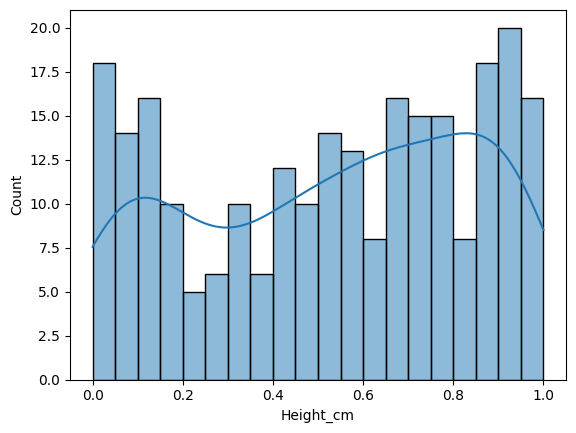

In [64]:
sns.histplot(X_Normalized['Height_cm'], bins = 20, kde = True)
# sns.histplot(X['Height_cm'], bins = 20, kde = True)

In [72]:
robust_scaler = RobustScaler()
X_RobustScaled = robust_scaler.fit_transform(X)
X_RobustScaled = pd.DataFrame(X_RobustScaled, columns = X.columns)
X_RobustScaled.describe()

,Height_cm
count,250.000000
mean,-0.092759
std,0.554019
min,-1.037975
25%,-0.620253
50%,0.000000
75%,0.379747
max,0.734177


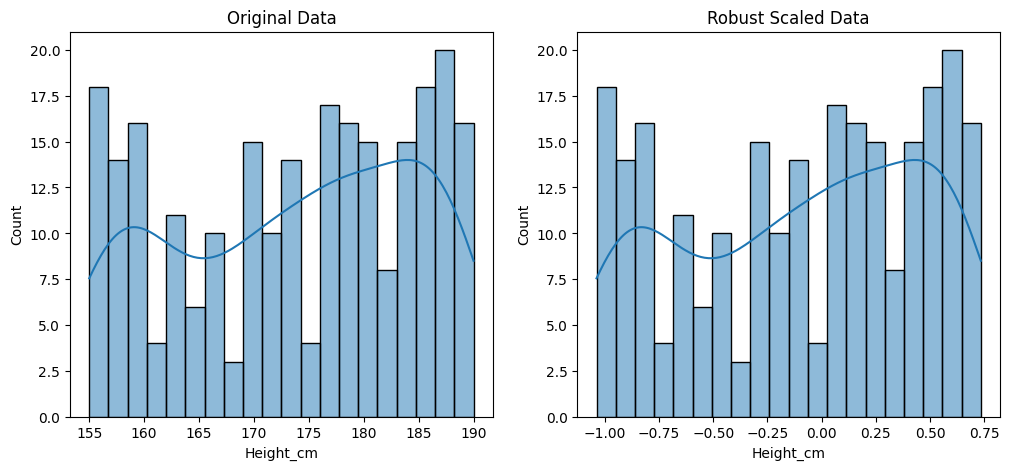

In [74]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].set_title('Original Data')
sns.histplot(X['Height_cm'], bins = 20, kde = True, ax = axes[0])
axes[1].set_title('Robust Scaled Data')
sns.histplot(X_RobustScaled['Height_cm'], bins = 20, kde = True, ax = axes[1])
plt.show()

In [ ]:
maxabs_scaler = MaxAbsScaler()
X_MaxAbsScaled = maxabs_scaler.fit_transform(X) 
X_MaxAbsScaled = pd.DataFrame(X_MaxAbsScaled, columns = X.columns)
X_MaxAbsScaled.describe()

,Height_cm
count,250.000000
mean,0.914042
std,0.057589
min,0.815789
25%,0.859211
50%,0.923684
75%,0.963158
max,1.000000


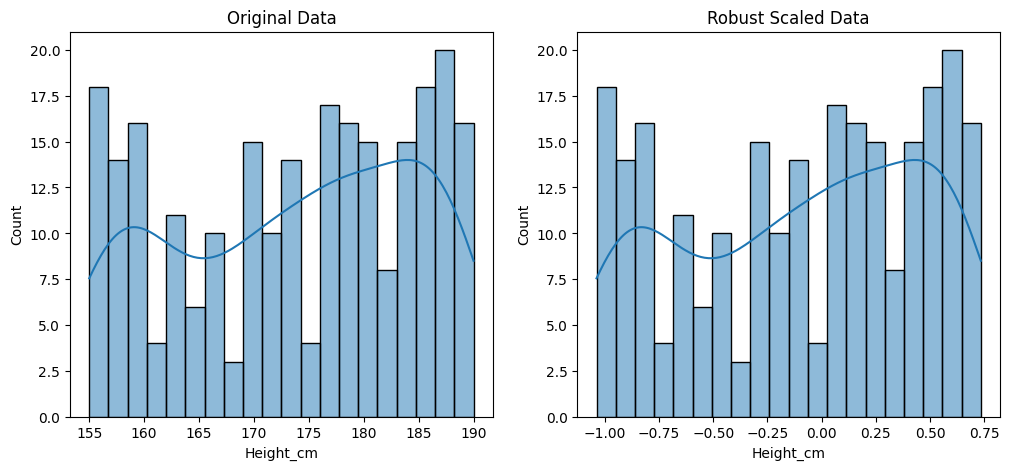

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5), )
axes[0].set_title('Original Data')
axes[1].set_title('MaX Absolute Scaled Data')
sns.histplot(X['Height_cm'], bins = 20, kde = True, ax = axes[0])
sns.histplot(X_MaxAbsScaled['Height_cm'], bins = 20, kde = True, ax = axes[1])
plt.show()